# **ML Classification Project**

## **Introduction**

### **Import Necessary Libraries**

In [15]:
#remove warning messages
import warnings
warnings.filterwarnings('ignore')

#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### **Import Dataset**

In [16]:
df = pd.read_csv("Telco_Customer_Churn.csv")

### **Display the first 5 rows**

In [17]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### **Display the last 5 rows**

In [18]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


### **Data Cleaning**

In [19]:
#Convert column name to standard type
df.columns = (df.columns
              .str.strip()
              .str.title()
              .str.replace(" ","_")
              .str.replace("-","_")
              )

In [20]:
#Check whether there is missing values

print(df.isnull().sum())

Customerid          0
Gender              0
Seniorcitizen       0
Partner             0
Dependents          0
Tenure              0
Phoneservice        0
Multiplelines       0
Internetservice     0
Onlinesecurity      0
Onlinebackup        0
Deviceprotection    0
Techsupport         0
Streamingtv         0
Streamingmovies     0
Contract            0
Paperlessbilling    0
Paymentmethod       0
Monthlycharges      0
Totalcharges        0
Churn               0
dtype: int64


In [21]:
df['Totalcharges'] = df['Totalcharges'].replace(' ', np.nan)
df['Totalcharges'] = df['Totalcharges'].astype(float)

df['Totalcharges'].fillna(df['Totalcharges'].median(), inplace=True)

In [22]:
#Check for duplicate values
df.duplicated().sum()

0

In [23]:
df = df.drop_duplicates()

In [24]:
#Drop column which is not at all necessary
#df = df.drop(columns=['Customerid'])
df.drop('Customerid', axis=1, inplace=True)

### **Data Understanding**

In [25]:
#Basic Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7043 non-null   object 
 1   Seniorcitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   Tenure            7043 non-null   int64  
 5   Phoneservice      7043 non-null   object 
 6   Multiplelines     7043 non-null   object 
 7   Internetservice   7043 non-null   object 
 8   Onlinesecurity    7043 non-null   object 
 9   Onlinebackup      7043 non-null   object 
 10  Deviceprotection  7043 non-null   object 
 11  Techsupport       7043 non-null   object 
 12  Streamingtv       7043 non-null   object 
 13  Streamingmovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  Paperlessbilling  7043 non-null   object 
 16  Paymentmethod     7043 non-null   object 


In [26]:
# Use summary statistics to understand distribution
df.describe()

,Seniorcitizen,Tenure,Monthlycharges,Totalcharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


##  **Data Analysis and visualization**

1. How many customers stayed and how many left?

No     5174
Yes    1869
Name: Churn, dtype: int64


AttributeError: Line2D.set() got an unexpected keyword argument 'kind'

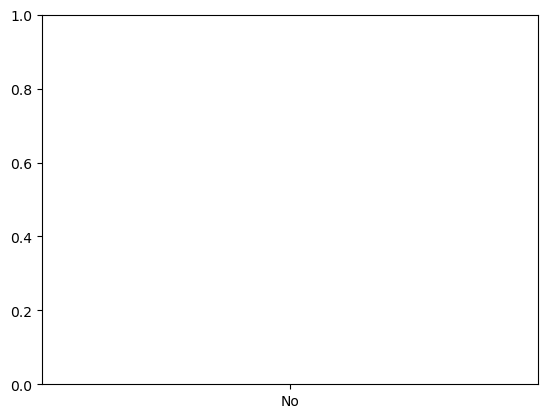

In [27]:
import matplotlib.pyplot as plt

count = df['Churn'].value_counts()
print(count)

#print(df['Churn'].value_counts())
plt.plot(count, kind='bar'


)

#df['Churn'].value_counts().plot(kind='bar', figsize=(6,4))

plt.title('Customers Who Stayed vs Left')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

Most customers stayed with the company, while a smaller portion left.
This shows that customer churn is a significant but not majority problem.

2. Do customers with longer tenure leave less?

In [ ]:
df.groupby('Churn')['tenure'].mean().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Average Tenure of Customers')
plt.xlabel('Churn')
plt.ylabel('Average Tenure (Months)')
plt.show()

print(df.groupby('Churn')['tenure'].mean())

Tenure means how many months the customer has been with the company.
Customers who have stayed for fewer months generally show a higher tendency to leave.
Long-term customers are usually more loyal.

3. Are customers paying more every month more likely to leave?
"Does a high monthly bill make customers leave?"

In [ ]:
df.groupby('Churn')['MonthlyCharges'].mean().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Average Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Average Monthly Charges')
plt.show()

If customers who leave have a higher average monthly charge,
it suggests that expensive monthly plans may be associated with higher churn.

4. Which type of contract has the most customers leaving?

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.show()

Month-to-month customers generally have much higher churn than customers
with one-year or two-year contracts.

Long-term contracts appear to encourage customers to stay.

5. Which payment method has the most customers leaving?"Does the way customers pay affect churn?"

In [ ]:
sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn'
)

plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.show()

Some payment methods have noticeably more churn than others.
If one payment method has a particularly high number of customers leaving,
the company could investigate whether those customers have a different
billing experience or customer profile.

6. Does internet service type affect customer churn?"Are customers using different internet services leaving at different rates?"

In [ ]:
sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn'
)

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

Churn differs between internet service types.
This suggests that the type of internet service a customer uses
may be related to their decision to leave.

7. Does having technical support reduce churn?"Do customers who have Tech Support stay longer?"

In [ ]:
sns.countplot(
    data=df,
    x='TechSupport',
    hue='Churn'
)

plt.title('Churn Based on Technical Support')
plt.xlabel('Technical Support')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.show()

Customers with technical support generally show lower churn than
customers without technical support.

This suggests that providing better support may help retain customers.

8. Are customers who pay more likely to leave?

In [ ]:
sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges of Customers')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

The distribution of monthly charges is different between customers who
stay and customers who leave.

If the churn group has a higher median charge, higher-priced services
may be one factor associated with customer churn.

How numerical variables are related to each other

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows how numerical variables are related.
Tenure and TotalCharges are expected to have a strong relationship because
customers who stay longer generally accumulate higher total charges.

## **Data Preprocessing**

In [ ]:
from sklearn import metrics

df = pd.get_dummies(df, drop_first=True)

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Logistic Regression Performance")
print("-" * 40)

print("Accuracy Score: ",metrics.accuracy_score(y_test, y_pred))
print("Confusion Matrix: \n",metrics.confusion_matrix(y_test, y_pred))
print("Classification Report: \n",metrics.classification_report(y_test, y_pred))

from sklearn.metrics import roc_auc_score
prob = model.predict_proba(X_test)[:,1]
print("ROC AUC Score: ",roc_auc_score(y_test, prob))

Logistic Regression Performance
----------------------------------------
Accuracy Score:  0.8197303051809794
Confusion Matrix: 
 [[933 103]
 [151 222]]
Classification Report: 
               precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

ROC AUC Score:  0.8620040473257631


### **KNN**

In [29]:
#Finding the best value of k
accuracy = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy.append(metrics.accuracy_score(y_test, y_pred))

best_k = accuracy.index(max(accuracy)) + 1
print("Best k:", best_k)
print("Best Accuracy:", max(accuracy))

Best k: 20
Best Accuracy: 0.8090844570617459


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=20)

knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

print("KNN Performance")
print("-" * 40)

# Evaluation
from sklearn import metrics
print("Accuracy :", metrics.accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))
print("Classification Report:\n", metrics.classification_report(y_test, y_pred))

# ROC-AUC
from sklearn.metrics import roc_auc_score
prob = knn.predict_proba(X_test)[:,1]
print("ROC-AUC Score :", roc_auc_score(y_test, prob))

KNN Performance
----------------------------------------
Accuracy : 0.8090844570617459
Confusion Matrix:
 [[937  99]
 [170 203]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC Score : 0.8412757357127331


### **Decision Tree Classifier**

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import roc_auc_score

# Create Decision Tree Model
dt = DecisionTreeClassifier(random_state=42)

# Train the Model
dt.fit(X_train, y_train)

# Make Predictions
y_pred = dt.predict(X_test)


# Prediction Probabilities
y_prob = dt.predict_proba(X_test)[:, 1]

# Evaluation Metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print Results
print("Decision Tree Classifier Performance")
print("-" * 40)
print("Accuracy :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC Score :", round(roc_auc, 4))

print("\nConfusion Matrix")
print(metrics.confusion_matrix(y_test, y_pred))

#print("\nClassification Report")
#print(metrics.classification_report(y_test, y_pred))

Decision Tree Classifier Performance
----------------------------------------
Accuracy : 0.7083
Precision : 0.4495
Recall : 0.4531
F1 Score : 0.4513
ROC-AUC Score : 0.6283

Confusion Matrix
[[829 207]
 [204 169]]


#### Feature Importance

In [32]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

                                  Feature  Importance
1                                  Tenure    0.204891
2                          Monthlycharges    0.202813
3                            Totalcharges    0.196676
10            Internetservice_Fiber optic    0.103833
26                   Paperlessbilling_Yes    0.024914
28         Paymentmethod_Electronic check    0.024370
0                           Seniorcitizen    0.022011
4                             Gender_Male    0.022008
6                          Dependents_Yes    0.021366
13                     Onlinesecurity_Yes    0.020337
5                             Partner_Yes    0.017824
17                   Deviceprotection_Yes    0.017632
27  Paymentmethod_Credit card (automatic)    0.015734
15                       Onlinebackup_Yes    0.015610
19                        Techsupport_Yes    0.013462


### **Random Forest Classifier**

In [ ]:
# Import Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import roc_auc_score

# Create Random Forest Model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

# Train the Model
rf.fit(X_train, y_train)

# Make Predictions
y_pred = rf.predict(X_test)

# Prediction Probabilities
y_prob = rf.predict_proba(X_test)[:, 1]

# Evaluation Metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print Results
print("Random Forest Classifier Performance")
print("-" * 40)
print("Accuracy :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC Score :", round(roc_auc, 4))

print("\nConfusion Matrix")
print(metrics.confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(metrics.classification_report(y_test, y_pred))

Random Forest Classifier Performance
----------------------------------------
Accuracy : 0.8155
Precision : 0.704
Recall : 0.5228
F1 Score : 0.6
ROC-AUC Score : 0.8622

Confusion Matrix
[[954  82]
 [178 195]]

Classification Report
              precision    recall  f1-score   support

       False       0.84      0.92      0.88      1036
        True       0.70      0.52      0.60       373

    accuracy                           0.82      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.81      0.82      0.81      1409



#### Feature Importance

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                           Feature  Importance
1                           Tenure    0.190231
3                     Totalcharges    0.168411
2                   Monthlycharges    0.119577
10     Internetservice_Fiber optic    0.067512
25               Contract_Two year    0.062925
28  Paymentmethod_Electronic check    0.053268
13              Onlinesecurity_Yes    0.036460
24               Contract_One year    0.034501
19                 Techsupport_Yes    0.025229
26            Paperlessbilling_Yes    0.020054


##### Top 10 Important Features Plot

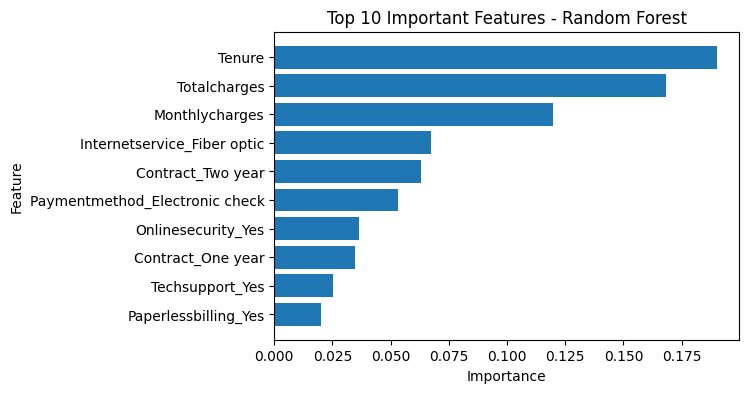

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(6,4))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()

### **Gaussian Naive Bayes**

In [ ]:
# Import Libraries
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import roc_auc_score

# Create Gaussian Naive Bayes Model
gnb = GaussianNB()

# Train the Model
gnb.fit(X_train, y_train)

# Make Predictions
y_pred = gnb.predict(X_test)

# Prediction Probabilities
y_prob = gnb.predict_proba(X_test)[:, 1]

# Evaluation Metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print Results
print("Gaussian Naive Bayes Performance")
print("-" * 40)
print("Accuracy :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC Score :", round(roc_auc, 4))

print("\nConfusion Matrix")
print(metrics.confusion_matrix(y_test, y_pred))

#print("\nClassification Report")
#print(metrics.classification_report(y_test, y_pred))

Gaussian Naive Bayes Performance
----------------------------------------
Accuracy : 0.665
Precision : 0.4351
Recall : 0.8901
F1 Score : 0.5845
ROC-AUC Score : 0.8381

Confusion Matrix
[[605 431]
 [ 41 332]]

Classification Report
              precision    recall  f1-score   support

       False       0.94      0.58      0.72      1036
        True       0.44      0.89      0.58       373

    accuracy                           0.67      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.80      0.67      0.68      1409



### **Support Vector Machine (SVM)**

In [ ]:
# Import Libraries
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import roc_auc_score

# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# Create SVM Model
svm = SVC(kernel='rbf',probability=True,random_state=0)

# Train the Model
svm.fit(X_train, y_train)

# Make Predictions
y_pred = svm.predict(X_test)

# Prediction Probabilities
y_prob = svm.predict_proba(X_test)[:, 1]

# Evaluation Metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print Results
print("Support Vector Machine (SVM) Performance")
print("-" * 45)
print("Accuracy :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC Score :", round(roc_auc, 4))

print("\nConfusion Matrix")
print(metrics.confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(metrics.classification_report(y_test, y_pred))

Support Vector Machine (SVM) Performance
---------------------------------------------
Accuracy : 0.8141
Precision : 0.6934
Recall : 0.5335
F1 Score : 0.603
ROC-AUC Score : 0.823

Confusion Matrix
[[948  88]
 [174 199]]

Classification Report
              precision    recall  f1-score   support

       False       0.84      0.92      0.88      1036
        True       0.69      0.53      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.81      1409



## **Model Comparison Table**

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Algorithm': ['Logistic Regression','KNN','Decision Tree','Random Forest','Naive Bayes','SVM'],
    'Accuracy': [0.8197, 0.7708, 0.7097, 0.8155, 0.6650, 0.8141],
    'Precision': [0.6800, 0.5740, 0.4519, 0.7040, 0.4351, 0.6934],
    'Recall': [0.5952, 0.5201, 0.4531, 0.5228, 0.8901, 0.5335],
    'F1 Score': [0.6348, 0.5458, 0.4525, 0.6000, 0.5845, 0.6030],
    'ROC-AUC': [0.8620, 0.7895, 0.6292, 0.8622, 0.8381, 0.8230]
})
results

,Algorithm,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8197,0.6800,0.5952,0.6348,0.8620
1,KNN,0.7708,0.5740,0.5201,0.5458,0.7895
2,Decision Tree,0.7097,0.4519,0.4531,0.4525,0.6292
3,Random Forest,0.8155,0.7040,0.5228,0.6000,0.8622
4,Naive Bayes,0.6650,0.4351,0.8901,0.5845,0.8381
5,SVM,0.8141,0.6934,0.5335,0.6030,0.8230


## **Model Comparision Bar Chart**

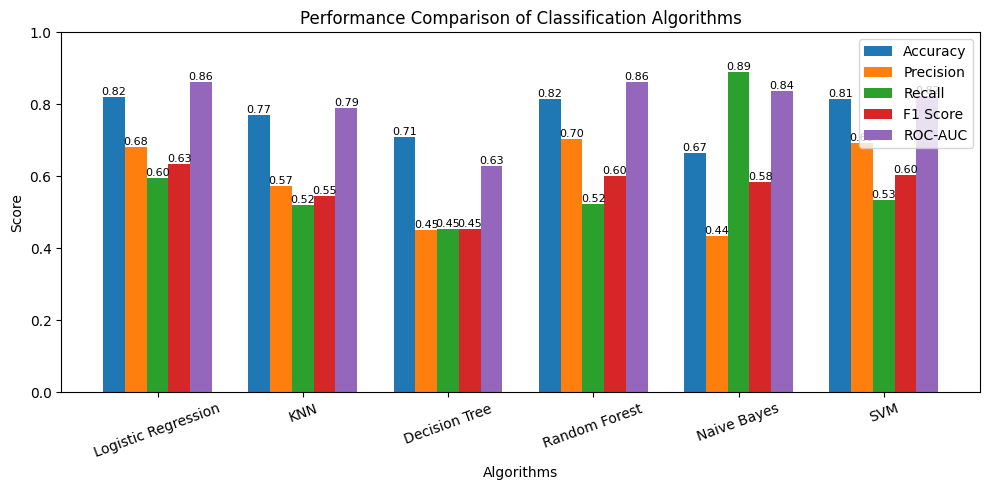

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# X-axis positions
x = np.arange(len(results['Algorithm']))
width = 0.15

plt.figure(figsize=(10,5))

plt.bar(x - 2*width, results['Accuracy'], width, label='Accuracy')
plt.bar(x - width, results['Precision'], width, label='Precision')
plt.bar(x, results['Recall'], width, label='Recall')
plt.bar(x + width, results['F1 Score'], width, label='F1 Score')
plt.bar(x + 2*width, results['ROC-AUC'], width, label='ROC-AUC')

plt.xticks(x, results['Algorithm'], rotation=20)
plt.xlabel('Algorithms')
plt.ylabel('Score')
plt.title('Performance Comparison of Classification Algorithms')

plt.ylim(0, 1)

plt.legend()

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', fontsize=8)

plt.tight_layout()

plt.show()

Best Model

In [ ]:
best_model = results.loc[results['Accuracy'].idxmax()]

print(best_model)

NameError: name 'results' is not defined

### **Conclusion**

This project compared six machine learning classification algorithms to predict customer churn using the Telco Customer Churn dataset.

Among all the models, Logistic Regression achieved the highest classification accuracy of 81.97%, along with a strong ROC-AUC score of 0.8620, indicating excellent capability in distinguishing between customers who churn and those who do not. Random Forest delivered nearly identical performance, achieving an accuracy of 81.55% and a slightly higher ROC-AUC score of 0.8622, making it another highly effective model.

Support Vector Machine also demonstrated competitive performance with an accuracy of 81.41%, while K-Nearest Neighbors and Decision Tree produced comparatively lower predictive performance. Gaussian Naive Bayes achieved the highest recall (89.01%), making it effective at identifying churning customers, but its overall accuracy and precision were lower due to a higher number of false positive predictions.

Overall, Logistic Regression was selected as the best-performing model because it provided the highest accuracy while maintaining balanced precision, recall, F1-score, and ROC-AUC, making it the most reliable classifier for this dataset.